<span style="color:red;font-size:1.5em;font-weight:bold;background-color:yellow">P10 - Evaluez les performances d'un LLM</span>

- Data scientist chez SportSee, une startup spécialisée dans l’IA appliquée à l’analyse de la performance sportive. On cherche ici à aider les entraîneurs, analystes et préparateurs physiques à trouver plus rapidement les informations clés pour préparer les entraînements, les matchs ou suivre la progression des athlètes de la NBA.

- **Contexte**: L'équipe à developpé un prototype d'assistant IA qui donne des résultats encourageants sur les archives textuelles mais perd le fil lorsqu'il s'agit de questions statistiques comme "Quel joueur a le meilleur pourcentage de réussite à 3 points sur les 5 derniers matchs ?" ou "Compare les statistiques de rebonds de l'équipe à domicile et à l'extérieur."

- **Objectif**: Améliorer l'assistant afin qu'il soit capable de répondre à des questions sémantiques, tabulaires ou hybrides en refactorant et en documentant le travail.

In [1]:
# Module pour recharger un module sans redemarrer le kernel
# import importlib
%load_ext autoreload
%autoreload 2

In [2]:
#Imports
from pathlib import Path
import numpy as np
import pandas as pd

In [3]:
# Sert à éviter les Warnings avec les transformations sur des vues en transformant 
# ces warning en erreur obligeant ainsi à ne travailler que sur des copies ou les originaux.

pd.set_option('mode.chained_assignment','raise')

In [4]:
# Ajoute le dossier datas_manipulation au sys.path. Remarque ne pas oublier le __init__.py dans le dossier datas_manipulation
import sys
# root_path = Path(__file__).resolve().parents[1] # Ne fonctionne pas sur notebook
ROOT_PATH = Path.cwd().parent
sys.path.append(str(ROOT_PATH))

In [5]:
ROOT_PATH

PosixPath('/home/shipoz/Documents/OPENCLASSROOMS/P10/livrable_P10')

In [20]:
# Chemin des données brutes
EXCEL_FILE = ROOT_PATH/"datas/inputs"/"regular NBA.xlsx"
IMG_PATH = ROOT_PATH/"datas"/"misc"/"images"

<span style="color:blue;font-size:1.2em;font-weight:bold;background-color:yellow">Analyse des différents fichiers du zip</span>

On regarde dans un premier temps ce qui nous a été fourni:

```bash
tree -I "__pycache__|.logfire|.venv|.vscode|__init__.py|notebooks|.env.example"
```

```text
.
├── indexer.py
├── inputs
│   ├── Reddit 1.pdf
│   ├── Reddit 2.pdf
│   ├── Reddit 3.pdf
│   ├── Reddit 4.pdf
│   └── regular NBA.xlsx
├── MistralChat.py
├── README.md
├── requirements.txt
├── utils
│   ├── config.py
│   ├── data_loader.py
│   └── vector_store.py
└── vector_db
    ├── document_chunks.pkl
    └── faiss_index.idx
```

Composant|Fichier(s)|Rôle Actuel|Limite Identifiée
|------|------|------|------|
|Paramètres|``config.py``|Centralise les paramètres du projet en un seul endroit|...|
|Ingestion|``indexer.py``|Découpe les PDF (Reddit) et l'Excel en chunks textuels.|Critique : Traiter un fichier ``.xlsx`` comme du texte brut perd toute la structure tabulaire.|
|Vector Store|``utils/vector_store.py``|Gère l'index FAISS et le stockage des vecteurs.|FAISS est excellent pour la sémantique, mais incapable d'agréger ou de comprendre la nuance des nombres.|
|Modèles|``MistralChat.py``|Interface avec l'API Mistral (``mistral-small`` et ``mistral-embed``).|Le modèle reçoit des morceaux de tableaux Excel mal formatés en contexte.|
|Data Loader|``utils/data_loader.py``|Extraction des fichiers brutes et constitution d'une liste de documents brutes.|Tente d'extraire les informations brutes textuelles ou numériques de façon similaire pour indexation.|
|Persistence|``vector_db/``|Stocke l'index (``.idx``) et les textes associés (``.pkl``).|...|

<span style="color:red;font-size:1.2em;font-weight:bold;background-color:blue">pdf et excel</span>

4 pdf: ``Reddit 1,2,3,4`` et 1 excel ``regular NBA.xlsx``

Les pdf sont des impressions de sujets de discussions en anglais sur la NBA sur le site Reddit. Ces impressions datent de 2025 et sont notamment pollués par les headers, les onglets, les marquages de trending, les pubs (qui sont par ailleurs en français), etc...

* **``Reddit 1.pdf``** "Who are the teams in the playoffs that have impressed you?" rassemblent des utilisateurs pour débattre des équipes qui se sont démarquées pendant les éliminatoires. Composé de 15 pages dont les 3 dernières sont des extraits avec titre de sujets similaires.

* **``Reddit 2.pdf``** "How is it that the two best teams in the playoffs based on stats, having a chance of playing against each other in the Finals, is considered to be a snoozefest?" ouvre une discussion sur le fait que le fait qu'une finale entre les deux meilleures équipes de l'étape éliminatoire serait mortellement ennuyeuse. 23 pages et encore une fois, les trois dernières sont entièrement consacrées aux sujets similaires.

* **``Reddit 3.pdf``** "Reggie Miller is the most efficient first option in NBA playoff history" est une discussion sur le joueur en question. 36 pages et on peut considérer que les 4 dernières sont un stack de sujets similaires.

* **``Reddit 4.pdf``** "Which NBA team did not have home court advantage until NBA Finals" interroge les utilisateurs pour savoir quelle(s) équipe(s) n'a pas pu bénéficier de l'avantage terrain sauf en finale en prenant pour exemple l'équipe "Edmonton Oilers". 10 pages et 3 dernières sur les sujets similaires.

* **``regular NBA.xlsx``** contient 5 feuilles:
    - *Données NBA*: Regroupe les données statistiques par joueur sur 45 colonnes dont la première "Player" est le nom et prénom du joueur.
    - *Analyse*: Semble être un exemple d'analyse tiré de la feuille *Analyse Vide* et qui se découpe en 4 parties. Une analyse de la saison NBA qui recense le scoring par équipe et nombre de joueurs, l'analyse d'une équipe qui va s'interesser aux rebonds et les actions types passe décisives; Puis un classement du top 15 des joueurs en terme de points et pour finir une section d'analyse complémentaire.
    - *Analyse Vide*: Semble être le template utilisé pour réaliser *Analyse*.
    - *Equipe*: Regroupe un code à 3 lettres avec le nom complet des équipes.
    - *Dictionnaire des données*: Lexique pour les abreviations utilisées notamment sur les colonnes de la page *Données NBA*.


In [14]:
df_stats = pd.read_excel(EXCEL_FILE,"Données NBA")
df_analyze = pd.read_excel(EXCEL_FILE,"Analyse")
df_team = pd.read_excel(EXCEL_FILE,"Equipe")
df_dict = pd.read_excel(EXCEL_FILE,"Dictionnaire des données")

In [13]:
df_stats

,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
0,Player,Team,Age,GP,W,L,Min,PTS,FGM,FGA,...,PIE,POSS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Shai Gilgeous-Alexander,OKC,26,76,63,13,34.2,2485,859,1657,...,19.9,5514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Anthony Edwards,MIN,23,79,48,31,36.3,2180,719,1612,...,14,5883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Nikola Jokić,DEN,30,70,46,24,36.7,2072,784,1365,...,20.6,5471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Giannis Antetokounmpo,MIL,30,67,40,27,34.2,2037,791,1320,...,21,4772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,Mac McClung,ORL,26,2,1,1,5.1,0,0,2,...,0,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
566,Terence Davis,SAC,28,1,1,0,7.9,0,0,2,...,0,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
567,Terry Taylor,SAC,25,3,1,2,2.1,0,0,1,...,4.3,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,Riley Minix,SAS,24,1,0,1,6.8,0,0,1,...,3.9,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Remarque: Les colonnes 46 à 53 sont vides

In [15]:
df_analyze

,Analyse de la saison de NBA,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Code,Nom complet de l'équipe,Nombre de joueur par équipe,Nombre de point total par équipe,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df_team

,Code,Nom complet de l'équipe
0,ATL,Atlanta Hawks
1,BKN,Brooklyn Nets
2,BOS,Boston Celtics
3,CHA,Charlotte Hornets
4,CHI,Chicago Bulls
5,CLE,Cleveland Cavaliers
6,DAL,Dallas Mavericks
7,DEN,Denver Nuggets
8,DET,Detroit Pistons
9,GSW,Golden State Warriors


In [17]:
df_dict

,Dictionnaire des données,Unnamed: 1
0,Player,Nom du joueur
1,Team,Équipe du joueur (code à 3 lettres)
2,Age,Âge du joueur
3,GP,Nombre de matchs joués (Games Played)
4,W,Nombre de victoires de l'équipe lors des match...
5,L,Nombre de défaites
6,Min,Minutes moyennes jouées par match
7,PTS,Points marqués en moyenne par match
8,FGM,Tirs réussis par match (Field Goals Made)
9,FGA,Tirs tentés par match (Field Goals Attempted)


<span style="color:red;font-size:1.2em;font-weight:bold;background-color:blue">config.py</span>

Centralise les clés API, les chemins (``vector_db()``), et les hyperparamètres (Taille des chunks : 1500, k=5).

<span style="color:red;font-size:1.2em;font-weight:bold;background-color:blue">data_loader.py --> Extracteur de données</span>

Charge et parse récursivement les sources d'un répertoire en une liste de dictionnaires.

Initie et utilise ``easyOCR`` en fallback a ``PyPDF2`` (même en cas d'un petit texte <100? etrange?)

**PROBLÈME MAJEUR**: 
1. Charge des excels et transforme les tableaux en chaîne de caractère via ``df.to_string()`` pour ensuite pouvoir chunker et indexer ==> Le LLM est excellent pour la sémantique mais mauvais en numérique. D'où l'utilisation par la suite de base de donnée.
**On va donc lui retirer les fonctions sur excel et csv par la suite.**
2. Le fichier réalise la fonction d'ETL cependant, la transformation est très légère (on ne cherche qu'à lui donner un format brute "standard" mais la donnée n'a pas été nettoyée). **Il faudra introduire une étape de nettoyage**

<span style="color:red;font-size:1.2em;font-weight:bold;background-color:blue">vectore_store.py --> Gestionnaire de mémoire</span>

Classe RAG qui possède trois méthodes: ``build_index()`` qui construit l'index FAISS, ``save_index_and_chunks()`` qui s'occupe de la persistence et ``search()`` sert de retriever.

A l'instanciation, l'objet va tenter de charger l'index et les chunks.

<span style="color:red;font-size:1.2em;font-weight:bold;background-color:blue">indexer.py --> Pipeline d'indexation</span>

Il dirige toute la pipeline de l'extraction de données brutes vers la persistence de l'index FAISS.

<span style="color:red;font-size:1.2em;font-weight:bold;background-color:blue">MistralChat.py --> Interface/Orchestrateur</span>

**Point d'entrée pour l'utilisateur**; Regroupe l'initialisation des ressources incluant le ``SYSTEM_PROMPT`` qui doit permettre d'orienter le LLM et la fonction ``generer_reponse()`` qui se charge de la partie Q\&A et créée aussi l'interface utilisateur Streamlit. Il récupère la question, interroge FAISS, construit le prompt avec le contexte et appelle le LLM.

**PROBLÈME MAJEUR**: Le ``SYSTEM_PROMPT`` est trop leger. Il dit au LLM *"réponds en animant le débat"*. Avec un index très bruité et parce que l'agent doit remplir un rôle spécifique, il va avoir beaucoup de mal à répondre de façon cohérente, précis sans halluciner.

<span style="color:blue;font-size:1.2em;font-weight:bold;background-color:yellow">Refactoring</span>

Le refactoring du prototype RAG a été nécéssaire car bien qu'il ait pu fonctionner en tant que tel, il y avait des conflits de versionnements si on souhaitait justement améliorer le système (ex: Conflit entre Mistral et Pydantic AI ainsi qu'avec RAGAS *cf image*)

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

(np.float64(-0.5), np.float64(922.5), np.float64(943.5), np.float64(-0.5))

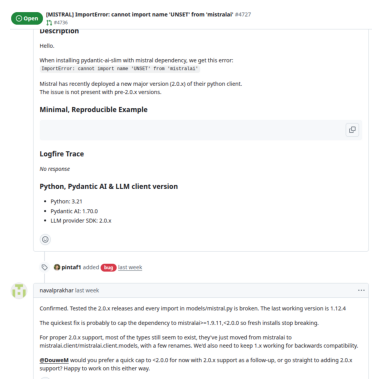

In [24]:
img_conflict = Image.open(IMG_PATH/"Capture d’écran du 2026-03-28 16-16-04.png")
plt.imshow(img_conflict)
plt.axis('off')

La réorganisation de l'infrastructure et le détail global des fichiers se trouve dans le ``README.md``.

<span style="color:blue;font-size:1.2em;font-weight:bold;background-color:yellow">Evaluation</span>

On va comparer les résultats RAGAS **avant puis après le refactoring**.

L'évaluation va permettre de juger de la pertinence de l'assistant sous différentes coutures en regardant sa capacité à rester dans le sujet (``Answer Relevancy``), à répondre correctement et sur tous les aspects demandés (``Faithfulness``) et à pointer vers les bonnes sources (``Context Recall``) (On a préféré éviter le ``Context Precision`` car les coûts sont déjà très elevé avec les prompts system etc...).
En plus d'un index opérationnel, il est nécéssaire de se constituer un ensemble de questions/réponses (Q&A) afin de pouvoir jauger de la fiabilité du RAG.

Les questions utilisées sont les suivantes:

```json
[
  {
    "question": "Existe-t-il une équipe NBA qui, à l'instar des Oilers d'Edmonton en NHL, a atteint les finales sans avoir l'avantage du terrain lors des trois premiers tours, pour finalement l'obtenir en finale ?",
    "ground_truth": "D'après les discussions, aucune équipe dans l'ère moderne de la NBA n'a réalisé ce parcours. Bien que six équipes aient atteint les finales avec une tête de série inférieure à 4, aucune d'entre elles n'a bénéficié de l'avantage du terrain une fois arrivée en finale."
  },
  {
    "question": "Quelles sont les critiques des fans concernant l'évolution du jeu de Shai Gilgeous-Alexander (SGA) par rapport aux légendes du passé ?",
    "ground_truth": "Certains fans critiquent SGA pour son recours excessif au 'flopping' et à la manipulation des fautes plutôt que de jouer de manière 'éthique'. Ils comparent négativement ce comportement à celui de légendes comme Kobe Bryant, Magic Johnson ou Michael Jordan, qui auraient cherché à marquer honnêtement."
  },
  {
    "question": "Quel joueur est considéré comme le meilleur 'first option' de l'histoire des playoffs et y-a-t'il des joueurs comparables en rTS et PPG dans la ligue actuelle?",
    "ground_truth": "Certains internautes considèrent Reggie Miller comme le meilleur 'first option' de l'histoire des playoffs. Avec un PPG a 24 sur plus de 100 matchs durant son prime (1991-2002) et un rTS de 115, il peut être considéré comme parmi les meilleurs. Si on ne se réfère qu'au PPG et au rTS, seuls 4 joueurs de la ligue ont fait aussi bien: Shai Gilgeous-Alexander, Nikola Jokić, Karl-Anthony Towns et Kevin Durant."
  }
]
```

On a ici, deux questions purement sémantique avec une première question plus difficile que la seconde (construction de la phrase difficile) et une question hybride très complexe car elle demande à regarder dans les discussions puis a comparer avec les données statistiques en plus de devoir agréger.

On a comparé les résultats à 3 moments:
1. Le prototype en tant que tel c'est à dire tout dans l'index et un prompt system vague (``Initial``).
2. Le retrait des ressources numériques de l'index avec db toujours avec le prompt de base (``After Basic Prompt``).
3. Le retrait des ressources numériques de l'index avec db ET un prompt system avancé, des few-shot prompts, des prompts SQL... (``After Improved Prompt``)

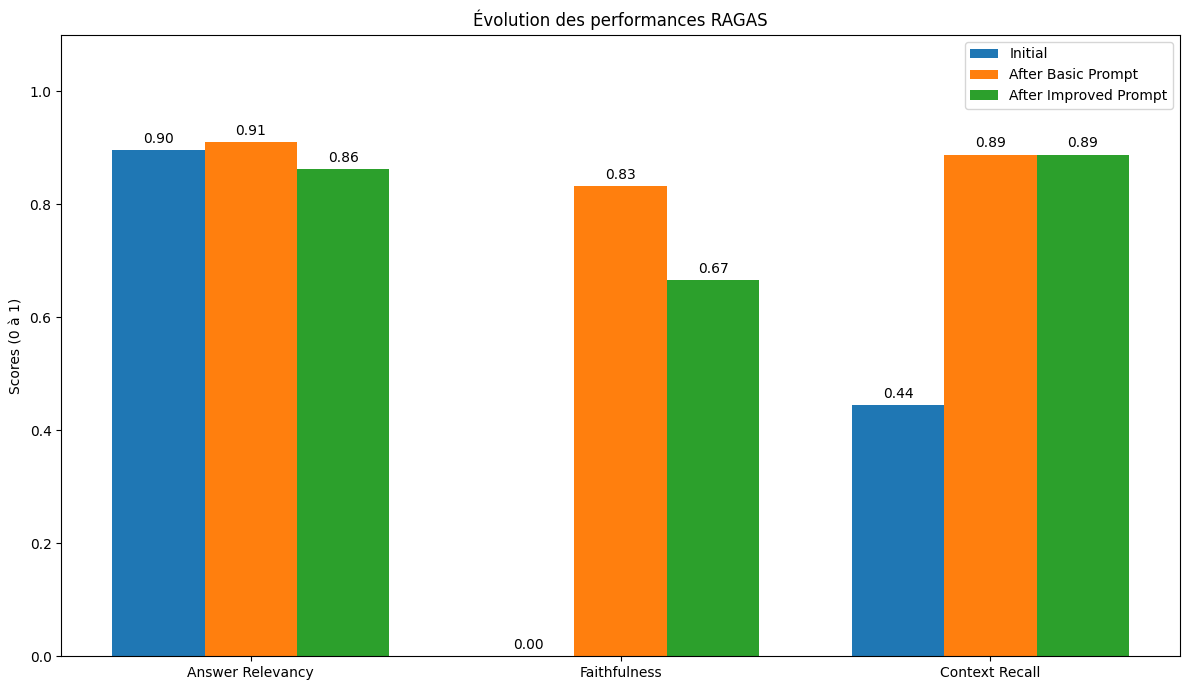

In [26]:
# Données
metrics = ["Answer Relevancy", "Faithfulness", "Context Recall"]
initial = [0.896, 0.0, 0.444]
after_basic = [0.910, 0.833, 0.888]
after_improve = [0.862, 0.666, 0.888]

x = np.arange(len(metrics))  # Emplacement des métriques sur l'axe X
width = 0.25  # Largeur des barres

fig, ax = plt.subplots(figsize=(12, 7))

# Création des barres
rects1 = ax.bar(x - width, initial, width, label='Initial')
rects2 = ax.bar(x, after_basic, width, label='After Basic Prompt')
rects3 = ax.bar(x + width, after_improve, width, label='After Improved Prompt')

# Ajout de texte, titres et légendes
ax.set_ylabel('Scores (0 à 1)')
ax.set_title('Évolution des performances RAGAS')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

# Ajout des étiquettes de valeur au-dessus des barres
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points de décalage vertical
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

**Lecture du graphique**

Ce qu'on observe dans un premier temps c'est qu'importe le système, tous arrivent à rester dans le sujet lorsqu'ils répondent avec un Answer Relevancy autour de 0.9.

Par contre on voit ensuite qu'en terme de fidélité, le cas initial à un score de 0 donc hallucination totale tandis que le cas avec un prompt amélioré a un score moyen et EN PLUS inférieur au cas sans prompt amélioré ce qui impliquerait que pour ragas, le cas amélioré à une plus grande tendance à inventer.

Puis côté contextuel, seul le cas initial n'arrive pas a retrouver correctement les informations dans l'index.

**Interprétation avancée**

A la seule lecture des résultats, on pourrait dire que le background du modèle mistral utilisé (``mistral-small-latest``) est un excellent menteur car il sait ne pas faire de hors sujet tout en inventant une réponse sans problème et de plus la séparation de la donnée textuelle et numérique a permis de grandement améliorer la fiabilité de l'assistant. On pourrait aussi croire qu'avoir amélioré le prompt à réduit les performance de l'assistant et que c'était une mauvaise idée CEPENDANT, en sachant que RAGAS ne se base QUE sur ce qu'on lui fournit, puisqu'il n'a pas accès à la base de donnée, les réponses qui se basent sur la base de donnée se traduisent par une hallucination pour RAGAS ce qui pourrait expliquer la dégradation du score de fidélité.

Ainsi si on regarde les réponses fournis par le LLM surtout sur la question hybride on peut voir que pour le cas intial, le modèle écrit des réponses à rallonge jusqu'à faire sauter la limitation de token et utilise très peu voir les documents et va plutôt chercher dans sa mémoire d'entrainement mistral. Dans le cas où le prompt reste basique, encore une fois, le modèle à du mal à se retenir de parler mais moins et arrive à beaucoup mieux se servir des documents de l'index bien qu'il aille aussi chercher dans sa mémoire, il semblerait. Enfin pour le cas avancé, les réponses sont concises et factuelles, ils réponse parfaitement aux demandes ce qui **confirme le fait que ce cas est le meilleur bien que le scoring de RAGAS ne le classerait que second parmi les trois**.

On a pu observer le scoring RAGAS et voir qu'il y a bien eu une amélioration des performance AVANT/APRÈS et on a pu voir les limites de RAGAS notamment sur sa limitation contextuelle ce qui est normal.

D'autres améliorations ont pu être observé en dehors de la boucle d'évaluation RAGAS, comme le fait qu'avec un prompt basique, le LLM ne sait pas être concis et factuel comme nous l'avions vu mais qu'en plus, il pouvait par exemple changer de langue entre deux questions, ou demander des informations inexistante ni agregeable dans la base de donnée etc... tandis qu'un prompt amélioré peut non seulement faire tout celà mais en plus sait borner ses réponses (*cf images*)

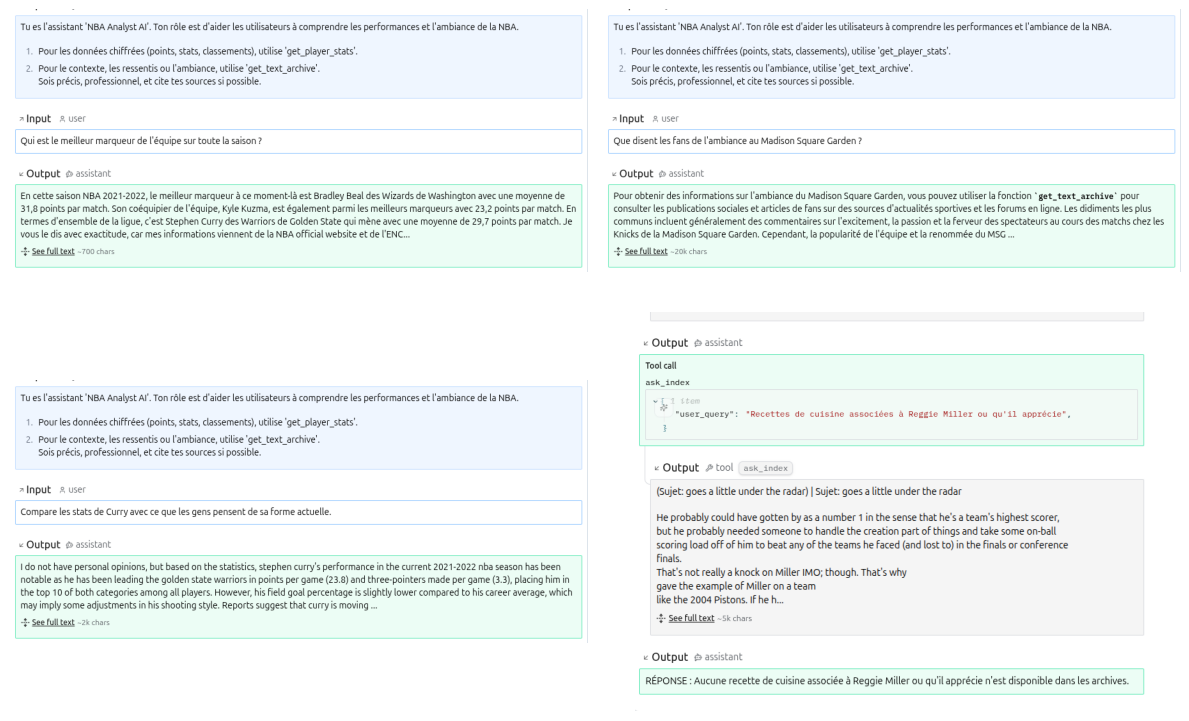

In [28]:
images = [
    Image.open(IMG_PATH/"Capture d’écran du 2026-03-30 14-26-55.png"),
    Image.open(IMG_PATH/"Capture d’écran du 2026-03-30 14-27-03.png"),
    Image.open(IMG_PATH/"Capture d’écran du 2026-03-30 14-27-17.png"),
    Image.open(IMG_PATH/"Capture d’écran du 2026-04-08 21-47-30.png")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# .flatten() permet de passer de axes[0,0], axes[0,1]... à une liste simple
axes_flat = axes.flatten()

for i,img in enumerate(images):
    axes_flat[i].imshow(img)
    axes_flat[i].axis('off')
plt.tight_layout()

En résumé après être passé d'une vectoristation totale des données en index à une séparation stricte entre la donnée non structurée de Reddit et la structurée de l'excel, on a pu observé une amélioration conséquente de l'assistant mais ce n'est qu'en combinant avec un prompt engineering avancé que le RAG est devenu non seulement fiable, robuste, concis et factuel. Malgré tout, il reste de nombreux défis et le système reste sujet à des erreurs et est donc encore très perfectible (Compromis token/prompt engineering, pas toujours capable de s'orienter directement vers le bon outil, n'est pas toujours critique de l'information transmise, fait parfois des raccourcis ou n'est pas capable de reconnaitre les variables de la base de données si elle sont trop subjective). En plus de ces limites, on a pu voir qu'une métrique seule ne suffisait pas du tout à évaluer un système, et même un groupe entier de métrique comme on a pu le voir avec les deux cas "APRÈS", enfin on a employer mistral pour juger de mistral ce qui peut biaiser son rôle de juge dans le RAGAS.